# Model Preparation and Baseline Model


## Introduction

The previous notebooks focused on understanding the dataset, exploratory analysis, statistical testing, and multivariate relationships.

The purpose of this notebook is to prepare the selected features for machine learning and establish a baseline churn prediction model.

The main steps will include:
- defining the target variable and predictor features,
- splitting the data into training and test sets,
- preprocessing numerical and categorical variables,
- building a preprocessing pipeline,
- training a baseline Logistic Regression model,
- evaluating its predictive performance.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from sklearn.metrics import ConfusionMatrixDisplay



df = pd.read_csv("../data/processed/telco_customer_churn_cleaned.csv")

In [2]:
selected_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

In [3]:
X = df[selected_features]

y = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

X.shape

(7043, 20)

In [4]:
y.value_counts()

Churn Label
0    5174
1    1869
Name: count, dtype: int64

In [5]:
y.value_counts(normalize=True)

Churn Label
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn Label
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn Label
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## Preprocessing Pipeline

The dataset contains both numerical and categorical features, which require different preprocessing steps before model training. Numerical features will be scaled, while categorical features will be transformed using one-hot encoding. All preprocessing steps must be reproducible and applicable to new unseen observations.



In [7]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

In [8]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Baseline Model Training

In [ ]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

model_pipeline.fit(X_train, y_train)

## Cross-Validation

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]
)

pd.DataFrame(cv_results)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision
0,0.071558,0.040745,0.811003,0.666667,0.575251,0.617594,0.862759,0.660120
1,0.065298,0.039152,0.790594,0.623529,0.531773,0.574007,0.838188,0.653038
2,0.067235,0.038204,0.808341,0.664032,0.561873,0.608696,0.851667,0.702055
3,0.053640,0.038635,0.826974,0.678082,0.662207,0.670051,0.872748,0.696969
4,0.056677,0.037690,0.823268,0.701613,0.581940,0.636197,0.868716,0.687173


In [11]:
cv_summary = pd.DataFrame({
    "Mean": {
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean(),
        "ROC-AUC": cv_results["test_roc_auc"].mean(),
        "PR-AUC": cv_results["test_average_precision"].mean()
    },
    "Std": {
        "Accuracy": cv_results["test_accuracy"].std(),
        "Precision": cv_results["test_precision"].std(),
        "Recall": cv_results["test_recall"].std(),
        "F1": cv_results["test_f1"].std(),
        "ROC-AUC": cv_results["test_roc_auc"].std(),
        "PR-AUC": cv_results["test_average_precision"].std()
    }
})

cv_summary

,Mean,Std
Accuracy,0.812036,0.012836
Precision,0.666785,0.025374
Recall,0.582609,0.043370
F1,0.621309,0.031647
ROC-AUC,0.858816,0.012524
PR-AUC,0.679871,0.019738


Logistic Regression provides a reasonably strong baseline model. The model achieves an average accuracy of approximately 81% and a ROC-AUC of approximately 0.86 across the five cross-validation folds. Precision is around 67%, indicating that roughly two thirds of customers predicted to churn actually churn. Recall is lower, at approximately 58%, meaning that the model fails to identify a substantial proportion of actual churn customers. The resulting F1-score of approximately 0.62 reflects this trade-off between precision and recall.

The default classification threshold of 0.50 is commonly used to convert predicted probabilities into class labels, but it is not necessarily the most suitable choice for a churn prediction problem. In this case, recall is relatively low at the default threshold, meaning that a substantial proportion of actual churn customers is not identified. Therefore, different probability thresholds are evaluated to examine the trade-off between precision and recall.

In [12]:
y_train_proba = cross_val_predict(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

In [13]:
thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_train_proba >= threshold).astype(int)

    precision = precision_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Predicted Churn": y_pred_threshold.sum()
    })

threshold_table = pd.DataFrame(threshold_results)

threshold_table

,Threshold,Precision,Recall,F1,Predicted Churn
0,0.20,0.491564,0.876923,0.629986,2667
1,0.25,0.521480,0.820067,0.637546,2351
2,0.30,0.556193,0.777926,0.648634,2091
3,0.35,0.584360,0.729766,0.649018,1867
4,0.40,0.606655,0.682943,0.642542,1683
5,0.45,0.634963,0.634114,0.634538,1493
6,0.50,0.666922,0.582609,0.621921,1306
7,0.55,0.697880,0.528428,0.601447,1132
8,0.60,0.723799,0.443478,0.549979,916
9,0.65,0.758571,0.355184,0.483827,700


The threshold analysis shows a clear trade-off between precision and recall. Lower thresholds increase recall and allow the model to identify more actual churn customers, but they also increase the number of false positives and reduce precision. Higher thresholds have the opposite effect. 

In practice, the final threshold is usually selected according to business priorities, such as the cost of missing a churn customer, the cost of unnecessary retention actions, or the available capacity of a retention campaign.

For this analysis, a threshold of 0.35 was selected as a reasonable compromise between precision and recall. At this threshold, the model achieves approximately 58% precision and 73% recall, while also producing the highest F1-score among the evaluated thresholds. This threshold will therefore be used as an alternative to the default 0.50 threshold during final model evaluation.

The threshold analysis is based entirely on out-of-fold predictions from the training data. The held-out test set is not used during baseline evaluation or threshold selection and is reserved for the final evaluation after model comparison and tuning.

## Feature Coefficients

In [22]:
model_pipeline.fit(X_train, y_train)

feature_names = (
    model_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    model_pipeline
    .named_steps["model"]
    .coef_[0]
)

In [23]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = (
    feature_importance
    .sort_values("Absolute Coefficient", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(20)

,Feature,Coefficient,Absolute Coefficient
0,num__Tenure Months,-1.279176,1.279176
1,cat__Dependents_Yes,-0.988252,0.988252
2,cat__Contract_Two year,-0.748249,0.748249
3,cat__Dependents_No,0.643730,0.643730
4,cat__Internet Service_DSL,-0.609322,0.609322
5,cat__Contract_Month-to-month,0.571353,0.571353
6,cat__Internet Service_Fiber optic,0.550958,0.550958
7,num__Total Charges,0.523226,0.523226
8,num__Monthly Charges,-0.502199,0.502199
9,cat__Paperless Billing_No,-0.351567,0.351567


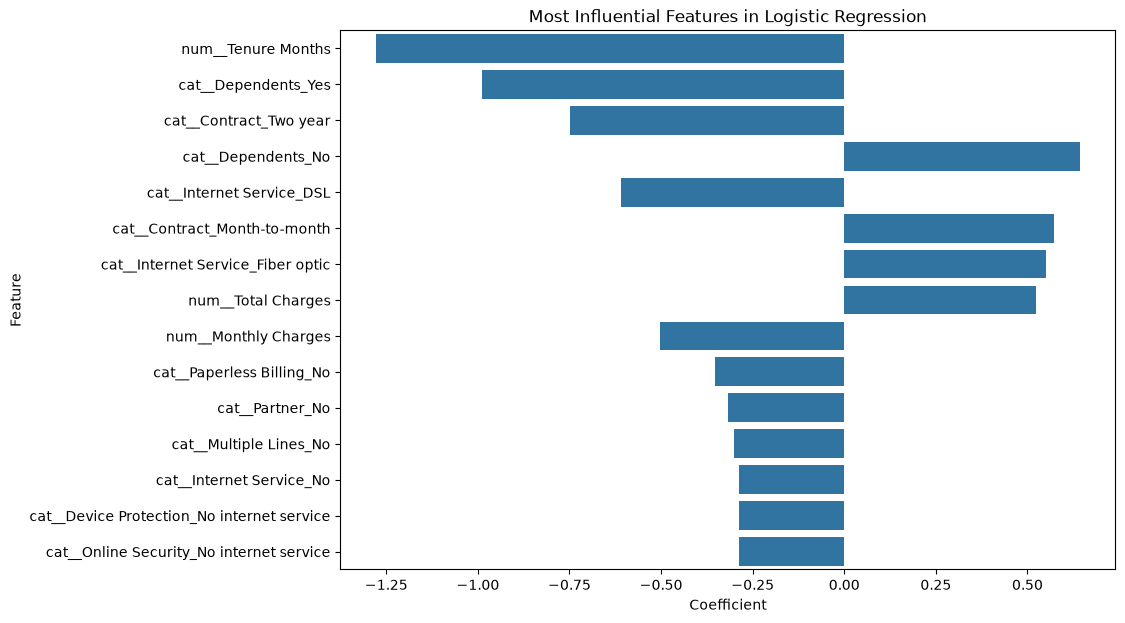

In [24]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Most Influential Features in Logistic Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

To better understand the baseline model, the learned Logistic Regression coefficients are examined. Positive coefficients are associated with higher predicted log-odds of churn, while negative coefficients are associated with lower predicted log-odds, conditional on the other variables in the model. Because all one-hot encoded categories are retained and the model is regularized, individual dummy coefficients should not be interpreted as simple effects relative to a single reference category. Their magnitudes should therefore be treated as indicative rather than as direct measures of feature importance.

## Final Findings

Logistic Regression provides a strong baseline model with good ranking performance. Cross-validated out-of-fold predictions show that lowering the classification threshold increases recall at the cost of lower precision and more false positives.

A threshold of 0.35 was selected as a reasonable recall-oriented operating point based only on the training data. The held-out test set remains reserved for the final model evaluation.